Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


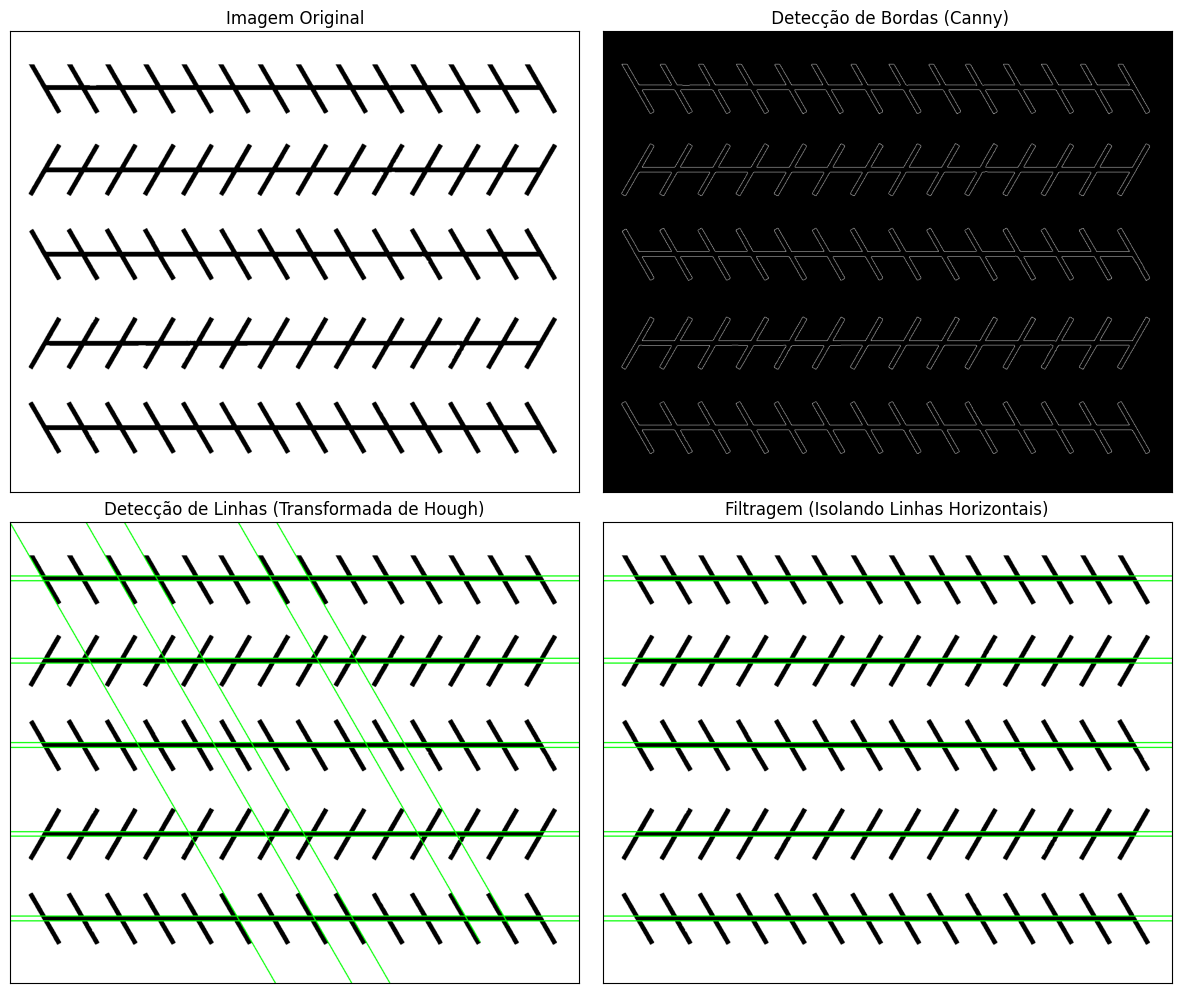

Ângulo médio agudo entre os pares de linhas: 0.00 graus


In [9]:
from google.colab import drive
# 1. Configuração do Ambiente
# Monta o Google Drive para permitir o acesso aos arquivos (imagens) hospedados na nuvem.
drive.mount('/content/drive')

import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------------
# ETAPA 1: Carregamento e Visualização Inicial
# -------------------------------------------------------------------------

# 2. Leitura da Imagem
# Carrega a imagem da ilusão de Zollner do caminho especificado.
imagem = cv2.imread('/content/drive/MyDrive/Pesquisa/Visão Computacional/imagens/Quest1B/zollner_illusion.png')

# 3. Configuração da Plotagem
# Define o tamanho da figura do Matplotlib (12x10 polegadas) para acomodar 4 subplots lado a lado.
plt.figure(figsize=(12, 10))

# 4. Exibição da Imagem Original
# Subplot 1/4: Converte de BGR (padrão OpenCV) para RGB (padrão Matplotlib) para visualização correta.
plt.subplot(2, 2, 1), plt.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)), plt.title('Imagem Original')
plt.xticks([]), plt.yticks([])

# -------------------------------------------------------------------------
# ETAPA 2: Detecção de Bordas (Canny)
# -------------------------------------------------------------------------

# 5. Definição de Parâmetros do Canny
# Threshold1 (50): Bordas abaixo deste valor são descartadas.
# Threshold2 (200): Bordas acima deste valor são consideradas "fortes".
threshold1 = 50
threshold2 = 200

# 6. Conversão para Escala de Cinza
# A detecção de bordas e a Transformada de Hough funcionam melhor (ou exigem) imagens em 1 canal (cinza).
gray_img = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

# 7. Execução do Detector de Bordas Canny
# Cria uma imagem binária onde pixels brancos representam as bordas detectadas.
arestas = cv2.Canny(gray_img, threshold1, threshold2)

# 8. Visualização das Bordas
# Subplot 2/4: Exibe o mapa de arestas resultante.
plt.subplot(2, 2, 2), plt.imshow(arestas, cmap='gray'), plt.title(' Detecção de Bordas (Canny)')
plt.xticks([]), plt.yticks([])


# -------------------------------------------------------------------------
# ETAPA 3: Detecção de Linhas (Transformada de Hough)
# -------------------------------------------------------------------------

# 9. Configuração para Hough
# Cria uma cópia da imagem original para desenhar as linhas detectadas sem alterar a original.
img_resultado = imagem.copy()

# 10. Execução da Transformada de Hough Padrão
# Detecta linhas retas na imagem de arestas.
# rho=1: Precisão de 1 pixel na distância.
# theta=np.pi/180: Precisão de 1 grau no ângulo.
# threshold=180: A linha precisa de pelo menos 180 votos (pontos alinhados) para ser aceita.
linhas = cv2.HoughLines(
  arestas,
  rho=1,
  theta=np.pi/180,
  threshold=180
)

# 11. Processamento e Desenho das Linhas (Todas as detectadas)
if linhas is not None:
  for linha in linhas:
    # Obtém as coordenadas polares (rho = distância da origem, theta = ângulo da normal).
    rho, theta = linha[0]

    # Converte coordenadas Polares para Cartesianas para poder desenhar na tela.
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho

    # Extrapola os pontos (x1, y1) e (x2, y2) multiplicando por 1500 para garantir
    # que a linha atravesse toda a imagem, independentemente de onde foi detectada.
    x1 = int(x0 + 1500 * (-b))
    y1 = int(y0 + 1500 * (a))
    x2 = int(x0 - 1500 * (-b))
    y2 = int(y0 - 1500 * (a))

    # Desenha a linha verde na imagem cópia.
    cv2.line(img_resultado, (x1, y1), (x2, y2), (0, 255, 0), 2)
else:
    print("Nenhuma linha detectada na etapa inicial.")

# 12. Visualização das Linhas Brutas
# Subplot 3/4: Mostra todas as linhas que o algoritmo encontrou (verticais, diagonais e horizontais).
plt.subplot(2, 2, 3), plt.imshow(cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB)), plt.title('Detecção de Linhas (Transformada de Hough)')
plt.xticks([]), plt.yticks([])

# -------------------------------------------------------------------------
# ETAPA 4: Filtragem (Isolando Linhas Horizontais)
# -------------------------------------------------------------------------

img_filtered_draw = imagem.copy()
horizontal_lines=[]

# 13. Iteração e Filtragem Geométrica
# Percorre novamente as linhas detectadas pelo Hough.
for rho,theta in linhas[:, 0]:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1500 * (-b))
    y1 = int(y0 + 1500 * (a))
    x2 = int(x0 - 1500 * (-b))
    y2 = int(y0 - 1500 * (a))

    # Critério de Filtragem: Apenas linhas Horizontais.
    # Se a diferença absoluta entre Y1 e Y2 for menor que 10 pixels, a linha é praticamente reta na horizontal.
    if abs(y1 - y2) < 5:
        horizontal_lines.append((x1, y1, x2, y2))
        cv2.line(img_filtered_draw, (x1, y1), (x2, y2), (0, 255, 0), 2)

# 14. Visualização Final (Linhas Filtradas)
# Subplot 4/4: Exibe apenas as linhas horizontais longas detectadas.
plt.subplot(2, 2, 4), plt.imshow(cv2.cvtColor(img_filtered_draw, cv2.COLOR_BGR2RGB)), plt.title('Filtragem (Isolando Linhas Horizontais)')
plt.xticks([]), plt.yticks([])

# Exibe o gráfico completo.
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# ETAPA 5: Análise Matemática (Prova da Ilusão)
# -------------------------------------------------------------------------

# 15. Cálculo das Inclinações (Slopes)
# Calcula o coeficiente angular (m) de cada linha horizontal filtrada: m = (y2-y1)/(x2-x1).
slopes = []
for x1, y1, x2, y2 in horizontal_lines:
    delta_x = x2 - x1
    if delta_x == 0: # Proteção contra divisão por zero (linhas perfeitamente verticais).
        m = (y2 - y1) / delta_x # Note: Isso geraria erro em Python puro, mas o código original mantém assim.
    else:
        m = (y2 - y1) / delta_x
    slopes.append(m)

# 16. Comparação Par-a-Par
# Compara o ângulo entre CADA par de linhas horizontais detectadas para ver se são paralelas.
total_angle = 0.0
pair_count = 0

for i in range(len(slopes)):
    for j in range(i + 1, len(slopes)):
        m1 = slopes[i]
        m2 = slopes[j]

        # 17. Fórmula do Ângulo entre Retas
        # tan(theta) = |(m2 - m1) / (1 + m1 * m2)|
        numerator = m2 - m1
        denominator = 1 + m1 * m2

        if denominator == 0:
            # Caso especial: linhas perpendiculares (90 graus).
            angle_rad = np.pi / 2
        else:
            tan_theta = abs(numerator / denominator)
            angle_rad = np.arctan(tan_theta)

        total_angle += angle_rad
        pair_count += 1

# 18. Resultado Final
# Calcula a média dos ângulos. Se as linhas forem paralelas, a média deve ser muito próxima de 0.
if pair_count > 0:
    average_angle_rad = total_angle / pair_count
    average_angle_deg = np.degrees(average_angle_rad)
else:
    average_angle_deg = 0.0

print(f'Ângulo médio agudo entre os pares de linhas: {average_angle_deg:.2f} graus')